Quantium Virtual Internship - Retail Strategy and Analytics - Task 1

In [1]:
#Loading needed libraries
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
import re
import matplotlib.pyplot as plt

In [2]:
print(os.getcwd())

/home/leda/Projects/Customer_segments


In [3]:
print(os.listdir())

['QVI_purchase_behaviour.csv', '.git', '.ipynb_checkpoints', 'README.md', 'QVI_transaction_data.xlsx', 'Retail_strategy.ipynb']


In [4]:
#Importing datasets
df_purchase = pd.read_csv("QVI_purchase_behaviour.csv")
df_transactions = pd.read_excel("QVI_transaction_data.xlsx")

Purchase dataset EDA

In [5]:
#Exploratory Data Analysis Purchase dataset
df_purchase.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [6]:
df_purchase.shape

(72637, 3)

In [7]:
df_purchase.dtypes

LYLTY_CARD_NBR       int64
LIFESTAGE           object
PREMIUM_CUSTOMER    object
dtype: object

In [8]:
df_purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [9]:
df_purchase.duplicated().sum()

0

Transaction dataset EDA

In [10]:
df_transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [11]:
df_transactions.shape

(264836, 8)

In [12]:
df_transactions.dtypes

DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64
dtype: object

In [13]:
# Changing the format for the attribute "Date"
df_transactions["DATE"] = pd.to_datetime(df_transactions["DATE"], origin = "1899-12-30", unit = "D")

In [14]:
df_transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [15]:
print(f'PROD_NAME: {df_transactions["PROD_NAME"].unique()}')
print(f'PROD_NAME: {df_transactions["PROD_NAME"].nunique()}')

PROD_NAME: ['Natural Chip        Compny SeaSalt175g' 'CCs Nacho Cheese    175g'
 'Smiths Crinkle Cut  Chips Chicken 170g'
 'Smiths Chip Thinly  S/Cream&Onion 175g'
 'Kettle Tortilla ChpsHny&Jlpno Chili 150g'
 'Old El Paso Salsa   Dip Tomato Mild 300g'
 'Smiths Crinkle Chips Salt & Vinegar 330g'
 'Grain Waves         Sweet Chilli 210g'
 'Doritos Corn Chip Mexican Jalapeno 150g'
 'Grain Waves Sour    Cream&Chives 210G'
 'Kettle Sensations   Siracha Lime 150g' 'Twisties Cheese     270g'
 'WW Crinkle Cut      Chicken 175g' 'Thins Chips Light&  Tangy 175g'
 'CCs Original 175g' 'Burger Rings 220g'
 'NCC Sour Cream &    Garden Chives 175g'
 'Doritos Corn Chip Southern Chicken 150g' 'Cheezels Cheese Box 125g'
 'Smiths Crinkle      Original 330g'
 'Infzns Crn Crnchers Tangy Gcamole 110g'
 'Kettle Sea Salt     And Vinegar 175g'
 'Smiths Chip Thinly  Cut Original 175g' 'Kettle Original 175g'
 'Red Rock Deli Thai  Chilli&Lime 150g' 'Pringles Sthrn FriedChicken 134g'
 'Pringles Sweet&Spcy BBQ 134g'

In [16]:
df_transactions["PROD_NAME"] = df_transactions["PROD_NAME"].str.lower()

In [17]:
print(f'PROD_NAME: {df_transactions["PROD_NAME"].unique()}')
print(f'PROD_NAME: {df_transactions["PROD_NAME"].nunique()}')

PROD_NAME: ['natural chip        compny seasalt175g' 'ccs nacho cheese    175g'
 'smiths crinkle cut  chips chicken 170g'
 'smiths chip thinly  s/cream&onion 175g'
 'kettle tortilla chpshny&jlpno chili 150g'
 'old el paso salsa   dip tomato mild 300g'
 'smiths crinkle chips salt & vinegar 330g'
 'grain waves         sweet chilli 210g'
 'doritos corn chip mexican jalapeno 150g'
 'grain waves sour    cream&chives 210g'
 'kettle sensations   siracha lime 150g' 'twisties cheese     270g'
 'ww crinkle cut      chicken 175g' 'thins chips light&  tangy 175g'
 'ccs original 175g' 'burger rings 220g'
 'ncc sour cream &    garden chives 175g'
 'doritos corn chip southern chicken 150g' 'cheezels cheese box 125g'
 'smiths crinkle      original 330g'
 'infzns crn crnchers tangy gcamole 110g'
 'kettle sea salt     and vinegar 175g'
 'smiths chip thinly  cut original 175g' 'kettle original 175g'
 'red rock deli thai  chilli&lime 150g' 'pringles sthrn friedchicken 134g'
 'pringles sweet&spcy bbq 134g'

In [18]:
pattern = r"\b(chip|chips|crips|crips|potato|potatoes)\b"

mask_has_chip = df_transactions["PROD_NAME"].str.contains(
    pattern,
    case = False,
    na = False,
    regex = True
)

df_no_chips = df_transactions[~mask_has_chip]

print(df_no_chips[["PROD_NAME"]])
print(f'Total rows without chip-related words: {len(df_no_chips)}')


                                       PROD_NAME
1                       ccs nacho cheese    175g
4       kettle tortilla chpshny&jlpno chili 150g
5       old el paso salsa   dip tomato mild 300g
7          grain waves         sweet chilli 210g
9          grain waves sour    cream&chives 210g
...                                          ...
264829  infuzions sourcream&herbs veg strws 110g
264831   kettle sweet chilli and sour cream 175g
264832             tostitos splash of  lime 175g
264833                  doritos mexicana    170g
264835             tostitos splash of  lime 175g

[193317 rows x 1 columns]
Total rows without chip-related words: 193317


In [19]:
print(f'PROD_NAME: {df_no_chips["PROD_NAME"].unique()}')
print(f'PROD_NAME: {df_no_chips["PROD_NAME"].nunique()}')

PROD_NAME: ['ccs nacho cheese    175g' 'kettle tortilla chpshny&jlpno chili 150g'
 'old el paso salsa   dip tomato mild 300g'
 'grain waves         sweet chilli 210g'
 'grain waves sour    cream&chives 210g'
 'kettle sensations   siracha lime 150g' 'twisties cheese     270g'
 'ww crinkle cut      chicken 175g' 'ccs original 175g'
 'burger rings 220g' 'ncc sour cream &    garden chives 175g'
 'cheezels cheese box 125g' 'smiths crinkle      original 330g'
 'infzns crn crnchers tangy gcamole 110g'
 'kettle sea salt     and vinegar 175g' 'kettle original 175g'
 'red rock deli thai  chilli&lime 150g' 'pringles sthrn friedchicken 134g'
 'pringles sweet&spcy bbq 134g' 'red rock deli sr    salsa & mzzrlla 150g'
 'red rock deli sp    salt & truffle 150g'
 'smiths thinly       swt chli&s/cream175g' 'kettle chilli 175g'
 'doritos mexicana    170g' 'smiths crinkle cut  french oniondip 150g'
 'natural chipco      hony soy chckn175g'
 'dorito corn chp     supreme 380g' 'twisties chicken270g'
 'smith

In [20]:
chip_brands = [
    "smiths", "kettle", "doritos", "twisties", "pringles",
    "tyrrells", "cheezels", "tostitos", "snbts", "rrd", "natural chipco", "ccs"
]

pattern = r"\b(chip|chips|crip|crips|potato|potatoes)\b"

df_transactions["is_chip"] = (
    df_transactions["PROD_NAME"].str.contains(pattern, case=False, na=False, regex=True) |
    df_transactions["PROD_NAME"].str.lower().str.contains("|".join([b.lower() for b in chip_brands]))
)

df_no_chips = df_transactions[~df_transactions["is_chip"]]

print(df_no_chips[["PROD_NAME"]].head(20))
print(f"Total non-chip rows: {len(df_no_chips)}")

                                   PROD_NAME
5   old el paso salsa   dip tomato mild 300g
7      grain waves         sweet chilli 210g
9      grain waves sour    cream&chives 210g
13          ww crinkle cut      chicken 175g
16                         burger rings 220g
17    ncc sour cream &    garden chives 175g
21    ncc sour cream &    garden chives 175g
22    infzns crn crnchers tangy gcamole 110g
25  old el paso salsa   dip tomato mild 300g
28      red rock deli thai  chilli&lime 150g
29    infzns crn crnchers tangy gcamole 110g
32  red rock deli sr    salsa & mzzrlla 150g
34   red rock deli sp    salt & truffle 150g
41          dorito corn chp     supreme 380g
46    infzns crn crnchers tangy gcamole 110g
47  infuzions thai sweetchili potatomix 110g
50     smith crinkle cut   mac n cheese 150g
55   infuzions bbq rib   prawn crackers 110g
56     grnwves plus btroot & chilli jam 180g
64  infuzions thai sweetchili potatomix 110g
Total non-chip rows: 57954


In [21]:
# Likely chip keywords
chip_keywords = [
    "chip","chips","crisp","crisps","potato","potatoes",
    "crinkle cut","tortilla","sensations","original"
]

# Known chip brands
chip_brands = [
    "smiths", "kettle", "doritos", "twisties", "pringles",
    "tyrrells", "cheezels", "tostitos", "snbts", "rrd", "natural chipco", "ccs",
]

# Obvious non-chip categories
non_chip_keywords = [
    "salsa","dip","prawn crackers","nuts","papadums","sweet","chocolate","cheese sticks"
]

# Lowercase product names for consistent matching
prod_lower = df_transactions["PROD_NAME"].str.lower()

# Step 1: Identify likely chips
is_chip = prod_lower.str.contains("|".join(chip_keywords), na=False) | \
          prod_lower.str.contains("|".join([b.lower() for b in chip_brands]), na=False)

# Step 2: Identify obvious non-chips
is_non_chip = prod_lower.str.contains("|".join(non_chip_keywords), na=False)

# Step 3: Final flag
df_transactions["is_chip_final"] = is_chip & (~is_non_chip)

# Rows that are definitely not chips
df_no_chips = df_transactions[~df_transactions["is_chip_final"]]

print(df_no_chips["PROD_NAME"].head(20))
print(f"Total non-chip rows: {len(df_no_chips)}")

5     old el paso salsa   dip tomato mild 300g
7        grain waves         sweet chilli 210g
9        grain waves sour    cream&chives 210g
16                           burger rings 220g
17      ncc sour cream &    garden chives 175g
21      ncc sour cream &    garden chives 175g
22      infzns crn crnchers tangy gcamole 110g
25    old el paso salsa   dip tomato mild 300g
28        red rock deli thai  chilli&lime 150g
29      infzns crn crnchers tangy gcamole 110g
31                pringles sweet&spcy bbq 134g
32    red rock deli sr    salsa & mzzrlla 150g
34     red rock deli sp    salt & truffle 150g
39    smiths crinkle cut  french oniondip 150g
41            dorito corn chp     supreme 380g
44       smiths crinkle cut  tomato salsa 150g
46      infzns crn crnchers tangy gcamole 110g
47    infuzions thai sweetchili potatomix 110g
55     infuzions bbq rib   prawn crackers 110g
56       grnwves plus btroot & chilli jam 180g
Name: PROD_NAME, dtype: object
Total non-chip rows: 64404


In [22]:
print(f'PROD_NAME: {df_no_chips["PROD_NAME"].unique()}')
print(f'PROD_NAME: {df_no_chips["PROD_NAME"].nunique()}')

PROD_NAME: ['old el paso salsa   dip tomato mild 300g'
 'grain waves         sweet chilli 210g'
 'grain waves sour    cream&chives 210g' 'burger rings 220g'
 'ncc sour cream &    garden chives 175g'
 'infzns crn crnchers tangy gcamole 110g'
 'red rock deli thai  chilli&lime 150g' 'pringles sweet&spcy bbq 134g'
 'red rock deli sr    salsa & mzzrlla 150g'
 'red rock deli sp    salt & truffle 150g'
 'smiths crinkle cut  french oniondip 150g'
 'dorito corn chp     supreme 380g'
 'smiths crinkle cut  tomato salsa 150g'
 'infuzions thai sweetchili potatomix 110g'
 'infuzions bbq rib   prawn crackers 110g'
 'grnwves plus btroot & chilli jam 180g'
 'kettle sweet chilli and sour cream 175g'
 'doritos salsa       medium 300g'
 'old el paso salsa   dip chnky tom ht300g'
 'woolworths mild     salsa 300g'
 'old el paso salsa   dip tomato med 300g' 'cheetos puffs 165g'
 'rrd sweet chilli &  sour cream 165g' 'woolworths medium   salsa 300g'
 'woolworths cheese   rings 190g' 'cheetos chs & bacon balls

Notes: This could be taken as products that don't represents chips and therefore we could proceed to set them apart in order to get the dataset clean.
However, as a result of further investigation it has been found that some of this are other chip brands, they will be included in the brands keywords.

In [23]:
#Chip keywords
chip_keywords = [
    "chip","chips","crisp","crisps","potato","potatoes",
    "crinkle cut","tortilla","sensations","original","rings","potatomix"
]

#Chip brands
chip_brands = [
    "smiths", "kettle", "doritos", "twisties", "pringles",
    "tyrrells", "cheezels", "tostitos", "snbts", "rrd", "natural chipco", "ccs", 
    "grain waves", "ncc", "red rock deli", "dorito", "infuzions", "rrd", "infzns",
    "grnwves", "cheetos"
]

#Non-chip categories
non_chip_keywords = [
    "salsa","dip","nuts","papadums","chocolate","cheese sticks"
]

#Lowercase product names
prod_lower = df_transactions["PROD_NAME"].str.lower()

#Identify likely chips
is_chip = prod_lower.str.contains("|".join(chip_keywords), na=False) | \
          prod_lower.str.contains("|".join([b.lower() for b in chip_brands]), na=False)

# Step 2: Identify obvious non-chips
is_non_chip = prod_lower.str.contains("|".join(non_chip_keywords), na=False)

# Step 3: Final flag
df_transactions["is_chip_final"] = is_chip & (~is_non_chip)

# Rows that are definitely not chips
df_no_chips = df_transactions[~df_transactions["is_chip_final"]]

print(df_no_chips["PROD_NAME"].head(20))
print(f"Total non-chip rows: {len(df_no_chips)}")

5      old el paso salsa   dip tomato mild 300g
25     old el paso salsa   dip tomato mild 300g
32     red rock deli sr    salsa & mzzrlla 150g
39     smiths crinkle cut  french oniondip 150g
44        smiths crinkle cut  tomato salsa 150g
63              doritos salsa       medium 300g
71     old el paso salsa   dip chnky tom ht300g
74               woolworths mild     salsa 300g
83     smiths crinkle cut  french oniondip 150g
87      old el paso salsa   dip tomato med 300g
114     old el paso salsa   dip tomato med 300g
131     old el paso salsa   dip tomato med 300g
149    smiths crinkle cut  french oniondip 150g
158              woolworths medium   salsa 300g
178    old el paso salsa   dip chnky tom ht300g
189    red rock deli sr    salsa & mzzrlla 150g
190       smiths crinkle cut  tomato salsa 150g
207    old el paso salsa   dip tomato mild 300g
220    smiths crinkle cut  french oniondip 150g
222    red rock deli sr    salsa & mzzrlla 150g
Name: PROD_NAME, dtype: object
Total non

In [24]:
df_transactions = df_transactions[df_transactions["is_chip_final"]]
df_transactions.head()
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243797 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            243797 non-null  datetime64[ns]
 1   STORE_NBR       243797 non-null  int64         
 2   LYLTY_CARD_NBR  243797 non-null  int64         
 3   TXN_ID          243797 non-null  int64         
 4   PROD_NBR        243797 non-null  int64         
 5   PROD_NAME       243797 non-null  object        
 6   PROD_QTY        243797 non-null  int64         
 7   TOT_SALES       243797 non-null  float64       
 8   is_chip         243797 non-null  bool          
 9   is_chip_final   243797 non-null  bool          
dtypes: bool(2), datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 17.2+ MB


In [25]:
df_transactions.drop(columns=["is_chip","is_chip_final"], inplace = True)

In [26]:
df_transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,243797,243797.000000,2.437970e+05,2.437970e+05,243797.000000,243797.000000,243797.000000
mean,2018-12-30 01:17:43.105780736,135.050960,1.355349e+05,1.351317e+05,56.166487,1.908284,7.352755
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,2018-09-30 00:00:00,70.000000,7.001000e+04,6.753800e+04,26.000000,2.000000,5.800000
50%,2018-12-30 00:00:00,130.000000,1.303720e+05,1.352060e+05,53.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.000000,2.030860e+05,2.026630e+05,86.000000,2.000000,8.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.802871,8.077656e+04,7.816603e+04,33.642980,0.662536,3.081209


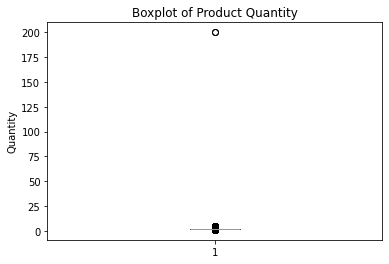

In [27]:
plt.boxplot(df_transactions["PROD_QTY"])
plt.title("Boxplot of Product Quantity")
plt.ylabel("Quantity")
plt.show()

In [28]:
count_200 = (df_transactions["PROD_QTY"] == 200).sum()
print(f'Number of transactions with quantity 200: {count_200}')

Number of transactions with quantity 200: 2


In [29]:
df_transactions[df_transactions["PROD_QTY"] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,dorito corn chp supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,dorito corn chp supreme 380g,200,650.0


In [30]:
df_transactions["PROD_QTY"].value_counts()

PROD_QTY
2      217505
1       25114
5         411
3         405
4         360
200         2
Name: count, dtype: int64

The sale for 200 was only twice and by the same customer, a quick check if the customer has made other purchases or is not a regular customer, to make decisions about this data.

In [31]:
df_transactions[df_transactions["LYLTY_CARD_NBR"] == 226000]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,dorito corn chp supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,dorito corn chp supreme 380g,200,650.0


The customer has just made those two big purchases, he is not a regular customer. He'll be removed from the dataset his purchase is way out of range compare to the other ones.

In [32]:
df_transactions = df_transactions.drop(
    df_transactions[df_transactions["LYLTY_CARD_NBR"] == 226000].index
)

In [33]:
df_transactions[df_transactions["LYLTY_CARD_NBR"] == 226000]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES


In [50]:
df_transactions_per_day = df_transactions.groupby("DATE").size().reset_index(name="count")

In [51]:
df_transactions_per_day.head()

,DATE,count
0,2018-07-01,656
1,2018-07-02,640
2,2018-07-03,661
3,2018-07-04,664
4,2018-07-05,650


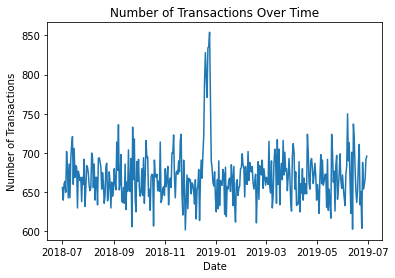

In [56]:
plt.figsize=(12,5))
plt.plot(df_transactions_per_day["DATE"],df_transactions_per_day["count"])
plt.title("Number of Transactions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.show()

In [58]:
df_transactions_per_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    364 non-null    datetime64[ns]
 1   count   364 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.8 KB


In [59]:
date_spine = pd.DataFrame({
    "DATE": pd.date_range(start="2018-07-01", end="2019-06-30")
})

transactions_per_day = df_transactions.groupby("DATE").size().reset_index(name = "TRANSACTIONS")

df_transactions_final = date_spine.merge(transactions_per_day, on = "DATE", how = "left")

df_transactions_final["TRANSACTIONS"] = df_transactions_final["TRANSACTIONS"].fillna(0)

print(df_transactions_final)

          DATE  TRANSACTIONS
0   2018-07-01         656.0
1   2018-07-02         640.0
2   2018-07-03         661.0
3   2018-07-04         664.0
4   2018-07-05         650.0
..         ...           ...
360 2019-06-26         654.0
361 2019-06-27         660.0
362 2019-06-28         667.0
363 2019-06-29         692.0
364 2019-06-30         696.0

[365 rows x 2 columns]


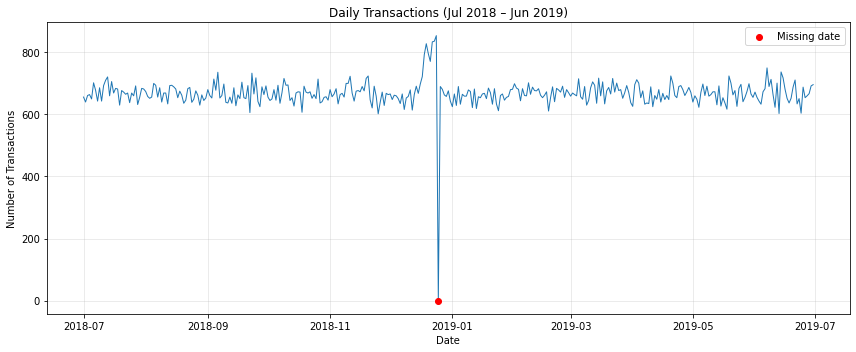

In [60]:
plt.figure(figsize=(12,5))
plt.plot(df_transactions_final['DATE'], df_transactions_final['TRANSACTIONS'], linewidth=1)

# Highlight missing day (where transactions == 0)
missing = df_transactions_final[df_transactions_final['TRANSACTIONS'] == 0]
plt.scatter(missing['DATE'], missing['TRANSACTIONS'], color='red', label='Missing date', zorder=5)

plt.title('Daily Transactions (Jul 2018 – Jun 2019)')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

There is an increase of purchases in December and a break at the end of the month. 

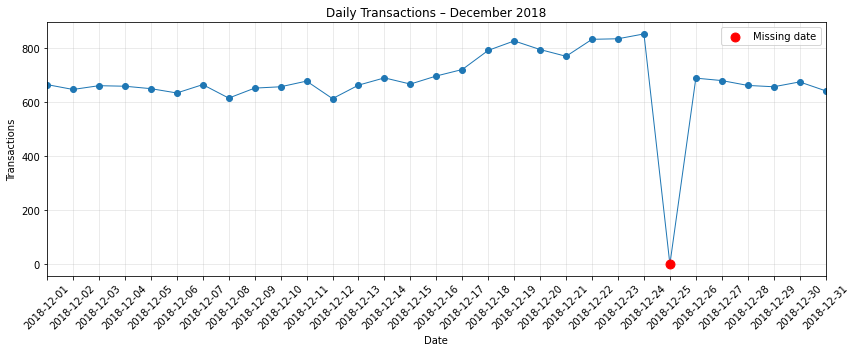

In [61]:
dec_df = df_transactions_final[
    (df_transactions_final['DATE'] >= '2018-12-01') &
    (df_transactions_final['DATE'] <= '2018-12-31')
].copy()

plt.figure(figsize=(12,5))
plt.plot(df_transactions_final['DATE'], df_transactions_final['TRANSACTIONS'], marker='o', linewidth=1)
plt.xlim(pd.Timestamp('2018-12-01'), pd.Timestamp('2018-12-31'))
    
missing = dec_df[dec_df['TRANSACTIONS'] == 0]
plt.scatter(missing['DATE'], missing['TRANSACTIONS'],
            color='red', s=80, label='Missing date', zorder=5)

plt.title('Daily Transactions – December 2018')
plt.xlabel('Date')
plt.ylabel('Transactions')
plt.xticks(dec_df['DATE'],rotation=45)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

The increase in sales occurs leading up to Christmas and it's zero sales on Christmas day. This day the shop was closed for Christmas day.
Tha data has no longer outlies.

In [63]:
df_transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,transactions_per_day
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,NaN
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,NaN
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,NaN
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0,NaN
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8,NaN


The data has no outliers so now new features such as Brand of chips and package size will be created

Creating new useful attributes

In [64]:
#Creating Brand attribute
df_transactions["BRAND"] = df_transactions["PROD_NAME"].str.split().str[0]
df_transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,transactions_per_day,BRAND
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,NaN,natural
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,NaN,ccs
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,NaN,smiths
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0,NaN,smiths
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8,NaN,kettle


In [65]:
print(f'BRAND: {df_transactions["BRAND"].unique()}')
print(f'BRAND: {df_transactions["BRAND"].nunique()}')

BRAND: ['natural' 'ccs' 'smiths' 'kettle' 'grain' 'doritos' 'twisties' 'ww'
 'thins' 'burger' 'ncc' 'cheezels' 'infzns' 'red' 'pringles' 'dorito'
 'infuzions' 'smith' 'grnwves' 'tyrrells' 'cobs' 'french' 'rrd' 'tostitos'
 'cheetos' 'woolworths' 'snbts' 'sunbites']
BRAND: 28


In [85]:
brand_map = {
    'ncc': 'Natural chip co.', 'natural': 'Natural chip co.', 
    'smith': 'Smiths', 'smiths': 'Smiths',
    'dorito': 'Doritos','doritos': 'Doritos',
    'infzns': 'Infuzions', 'infuzions': 'Infuzions',
    'rrd': 'Red Rock Deli', 'red': 'Red Rock Deli',
    'grnwves': 'Grain Waves', 'grain': 'Grain Waves',
    'snbts': 'Sunbites', 'sunbites': 'Sunbites',
    'ww': 'Woolworths', 'woolworths': 'Woolworths',
    'ccs': 'CCs', 'kettle': 'Kettle',
    'thins': 'Thins', 'cheezels': 'Cheezels', 
    'tostitos': 'Tostitos', 'cheetos': 'Cheetos', 
    'twisties': 'Twisties', 'pringles': 'Pringles', 
    'tyrrells': 'Tyrrells', 'cobs': 'Cobs',
    'french': 'French Fries', 'burger': 'Burger Rings'
}

In [86]:
df_transactions['BRAND'] = df_transactions['BRAND'].replace(brand_map)

In [87]:
print(f'BRAND: {df_transactions["BRAND"].unique()}')
print(f'BRAND: {df_transactions["BRAND"].nunique()}')

BRAND: ['Natural chip co.' 'CCS' 'Smiths' 'Kettle' 'Grain Waves' 'Doritos'
 'Twisties' 'Woolworths' 'Thins' 'Burger Rings' 'Cheezels' 'Infuzions'
 'Red Rock Deli' 'Pringles' 'Tyrrells' 'Cobs' 'French Fries' 'Tostitos'
 'Cheetos' 'Sunbites']
BRAND: 20


In [88]:
df_transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,transactions_per_day,BRAND,BRAND_CLEAN
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,NaN,Natural chip co.,Natural chip co.
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,NaN,CCS,ccs
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,NaN,Smiths,Smiths
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0,NaN,Smiths,Smiths
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8,NaN,Kettle,kettle


In [93]:
#Creating Package size
df_transactions["PACK_SIZE"] = df_transactions["PROD_NAME"].str.extract(r'(\d+)').astype(float)
df_transactions.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,transactions_per_day,BRAND,BRAND_CLEAN,Pack_size,PACK_SIZE
0,2018-10-17,1,1000,1,5,natural chip compny seasalt175g,2,6.0,NaN,Natural chip co.,Natural chip co.,175.0,175.0
1,2019-05-14,1,1307,348,66,ccs nacho cheese 175g,3,6.3,NaN,CCS,ccs,175.0,175.0
2,2019-05-20,1,1343,383,61,smiths crinkle cut chips chicken 170g,2,2.9,NaN,Smiths,Smiths,170.0,170.0
3,2018-08-17,2,2373,974,69,smiths chip thinly s/cream&onion 175g,5,15.0,NaN,Smiths,Smiths,175.0,175.0
4,2018-08-18,2,2426,1038,108,kettle tortilla chpshny&jlpno chili 150g,3,13.8,NaN,Kettle,kettle,150.0,150.0


In [94]:
df_transactions["PACK_SIZE"].describe()

count    243795.000000
mean        176.387079
std          59.172870
min          90.000000
25%         150.000000
50%         170.000000
75%         175.000000
max         380.000000
Name: PACK_SIZE, dtype: float64

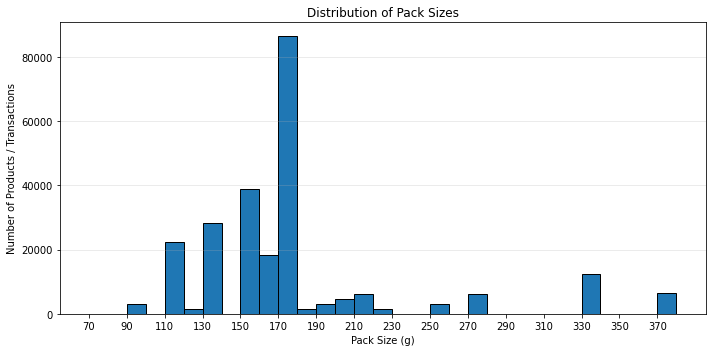

In [95]:
# Plot histogram
plt.figure(figsize=(10,5))
plt.hist(df_transactions['PACK_SIZE'].dropna(), bins=range(70, 385, 10), edgecolor='black')  # bins of 10g

plt.title('Distribution of Pack Sizes')
plt.xlabel('Pack Size (g)')
plt.ylabel('Number of Products / Transactions')
plt.xticks(range(70, 385, 20))  # nicer tick marks
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [97]:
# Count how many transactions per pack size
pack_size_counts = df_transactions.groupby('PACK_SIZE').size().reset_index(name='transaction_count')

# Sort descending to see most common
pack_size_counts = pack_size_counts.sort_values(by='transaction_count', ascending=False)

print(pack_size_counts.head(10))  # top 10 pack sizes

    PACK_SIZE  transaction_count
9       175.0              66390
5       150.0              38765
3       134.0              25102
1       110.0              22387
8       170.0              19983
7       165.0              15297
17      330.0              12540
18      380.0               6416
16      270.0               6285
13      210.0               6272
